**Table of contents**<a id='toc0_'></a>
- 1. [Лабораторная работа №2](#toc1_)
    - 1.1. [Описание задачи и признаков](#toc1_1_)
        - 1.1.1. [Постановка задачи](#toc1_1_1_)
        - 1.1.2. [Описание признакового пространства](#toc1_1_2_)
        - 1.1.3. [Формировка виртуального окружения](#toc1_1_3_)
            - 1.1.3.1. [Импорт библиотек](#toc1_1_3_1_)
            - 1.1.3.2. [Версия Python](#toc1_1_3_2_)
            - 1.1.3.3. [Фиксация seed для воспроизводимости результатов](#toc1_1_3_3_)
    - 1.2. [Предварительная обработка данных](#toc1_2_)
        - 1.2.1. [Загрузка данных](#toc1_2_1_)
        - 1.2.2. [Анализ данных](#toc1_2_2_)
        - 1.2.3. [Приведение типов данных и обработка некорректных значений](#toc1_2_3_)
            - 1.2.3.1. [Приведение пропусков к общему виду](#toc1_2_3_1_)
        - 1.2.4. [Удаление неинформативных признаков](#toc1_2_4_)
    - 1.3. [Разделение данных на обучающую и тестовую выборки](#toc1_3_)
        - 1.3.1. [Выделение целевого признака и предикторов](#toc1_3_1_)
        - 1.3.2. [Разбиение на обучающую и тестовую выборки](#toc1_3_2_)
- 2. [Лабораторная работа №3](#toc2_)
    - 2.1. [Кодирование категориальных признаков](#toc2_1_)
        - 2.1.1. [Выбор категориальных признаков](#toc2_1_1_)
        - 2.1.2. [Создание словаря соответствия](#toc2_1_2_)
        - 2.1.3. [Применение Ordinal Encoding к обучающей выборке](#toc2_1_3_)
        - 2.1.4. [Применение Ordinal Encoding к тестовой выборке](#toc2_1_4_)
    - 2.2. [Обработка пропущенных значений](#toc2_2_)
        - 2.2.1. [Определение признаков с пропусками](#toc2_2_1_)
        - 2.2.2. [Статистический подход (ручной выбор значения через KL-дивергенцию)](#toc2_2_2_)
        - 2.2.3. [Заполнение пропусков статистическими значениями в обучающей выборке](#toc2_2_3_)
        - 2.2.4. [Машинный подход (KNNImputer)](#toc2_2_4_)
        - 2.2.5. [Применение результатов к тестовой выборке](#toc2_2_5_)
    - 2.3. [Дополнительное задание: оценка качества заполнения пропусков (NRMSE)](#toc2_3_)
        - 2.3.1. [Создание «чистого» датасета](#toc2_3_1_)
        - 2.3.2. [Генерация маскированных данных](#toc2_3_2_)
        - 2.3.3. [Обучение KNNImputer на маскированных данных](#toc2_3_3_)
        - 2.3.4. [Вычисление NRMSE](#toc2_3_4_)

# 1. <a id='toc1_'></a>[Лабораторная работа №2](#toc0_)

## 1.1. <a id='toc1_1_'></a>[Описание задачи и признаков](#toc0_)

### 1.1.1. <a id='toc1_1_1_'></a>[Постановка задачи](#toc0_)

**Задача:** Прогнозирование коэффициента `Гармония Бессмертия` — ключевого показателя состояния магического портала "Врата Вечности".

**Тип задачи:** Задача **регрессии**, так как целевая переменная (`Гармония Бессмертия`) является непрерывной числовой величиной (коэффициент в диапазоне от 0 до 1).

**Цель:** Построить модель машинного обучения, которая по параметрам работы портала сможет предсказать значение его Гармонии. Это позволит заблаговременно обнаружить критический износ и предотвратить разрушение портала.

**Целевая переменная:**
- `Гармония Бессмертия`

**Входные данные:** 19 признаков, описывающих различные магические и физические параметры работы портала.

### 1.1.2. <a id='toc1_1_2_'></a>[Описание признакового пространства](#toc0_)

| **№** | Признак | Описание | Тип |
|---|---|---|---|
| | **Целевые признаки** | | |
| **1** | `Гармония Бессмертия` | Коэффициент, указывающий на состояние магического ядра портала и его стабильность | Вещественный(0-1) |
| | **Входные признаки** | | |
| **2** | `Вектор Мощи` | Позиция магического механизма, управляющего интенсивностью перехода через портал | Вещественный |
| **3** | `Скорость перехода через портал` | Скорость, с которой портал перемещает объект через пространство | Вещественный |
| **4** | `Приток Силы Потока` | Поток магической силы, текущий через ядро портала, обеспечивая стабильную работу | Вещественный |
| **5** | `Ритм магического ядра` | Число оборотов магического ядра портала в минуту | Вещественный |
| **6** | `Поток Энергий` | Число оборотов генератора эфира, преобразующего внешнюю энергию в магическую | Вещественный |
| **7** | `Сила Левого Потока` | Мощность магического потока, текущего через левую сторону портала | Вещественный |
| **8** | `Сила Правого Потока` | Мощность магического потока, текущего через правую сторону портала | Вещественный |
| **9** | `Пламя Стихий` | Температура магической энергии, исходящей из высокого магического источника портала (°C) | Вещественный |
| **10** | `Температура вдоха Истока` | Температура воздуха, входящего в магический ускоритель портала (°C) | Целочисленный |
| **11** | `Температура выдоха Истока` | Температура воздуха, исходящего из магического ускорителя портала (°C) | Вещественный |
| **12** | `Приток давления Выдоха Истока` | Давление магического потока на выходе из магического источника высокого давления | Вещественный |
| **13** | `Давление вдоха Истока` | Давление воздуха, входящего в магический ускоритель | Вещественный |
| **14** | `Давление выдоха Истока` | Давление воздуха, исходящего из магического ускорителя | Вещественный |
| **15** | `Древний Ветер` | Давление древней магической энергии, покидающей портал в виде выхлопного потока | Вещественный |
| **16** | `Печать Чародея` | Параметр управления магическим выбросом в сердце портала (%) | Вещественный |
| **17** | `Эмульсия Истока` | Количество магического топлива, подпитывающего портал | Вещественный |
| **18** | `Дыхание Истока` | Коэффициент, отображающий степень угасания магического ускорителя | Вещественный |
| **19** | `Тип Вектора Мощи` | Метка типа позиции магического механизма | Категориальный |
| **20** | `Номер пометки` | Уникальный номер записи о работе портала | Целочисленный |

### 1.1.3. <a id='toc1_1_3_'></a>[Формировка виртуального окружения](#toc0_)

#### 1.1.3.1. <a id='toc1_1_3_1_'></a>[Импорт библиотек](#toc0_)

In [36]:
import sys
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.stats import entropy
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

#### 1.1.3.2. <a id='toc1_1_3_2_'></a>[Версия Python](#toc0_)

In [37]:
print(f"Python: {sys.version}")

Python: 3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]


#### 1.1.3.3. <a id='toc1_1_3_3_'></a>[Фиксация seed для воспроизводимости результатов](#toc0_)

In [38]:
seed = 42
np.random.seed(seed)

## 1.2. <a id='toc1_2_'></a>[Предварительная обработка данных](#toc0_)

### 1.2.1. <a id='toc1_2_1_'></a>[Загрузка данных](#toc0_)

In [39]:
df = pd.read_csv('portal_data.csv', encoding='windows-1251', sep='|')

Вывод первых строк для проверки:

In [40]:
df.head()

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи,Номер пометки
0,1.138,1.54332,289.964,141.318158,6677.380,7.584,7.584,464.006,736,-,1.096,Не определено,5.947,-,7.137,0.082,0.95,0.975,Слабый,0
1,2.088,-,6960.180,144.111767,6828.469,28.204,28.204,635.401,736,581.658,1.331,1.394603,7.282,1.019,10.655,0.287,0.95,0.975,Слабый,1
2,3.144,4.6299600000000005,8379.229,145.220853,7111.811,60.358,60.358,606.002,736,-,1.389,Не определено,7.574,-,13.086,0.259,0.95,0.975,Ниже среднего,2
3,4.161,6.17328,14724.395,162.050156,7792.630,113.774,113.774,661.471,736,-,1.658,Не определено,9.007,-,18.109,0.358,0.95,0.975,Ниже среднего,3
4,5.140,7.7166,21636.432,201.513586,8494.777,175.306,175.306,731.494,736,645.642,2.078,Не определено,11.197,1.026,26.373,0.522,0.95,0.975,Выше среднего,4


### 1.2.2. <a id='toc1_2_2_'></a>[Анализ данных](#toc0_)

Общая информация о датасете:

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     11934 non-null  float64
 1   Скорость перехода через портал  11934 non-null  object 
 2   Приток Силы Потока              11934 non-null  float64
 3   Ритм магического ядра           11934 non-null  float64
 4   Поток Энергий                   11934 non-null  float64
 5   Сила Левого Потока              11934 non-null  float64
 6   Сила Правого Потока             11934 non-null  float64
 7   Пламя Стихий                    11934 non-null  float64
 8   Температура вдоха Истока        11934 non-null  int64  
 9   Температура выдоха Истока       11934 non-null  object 
 10  Приток давления Выдоха Истока   11934 non-null  float64
 11  Давление вдоха Истока           11934 non-null  object 
 12  Давление выдоха Истока          

In [42]:
df.describe()

,Вектор Мощи,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Номер пометки
count,11934.000000,11934.000000,11934.000000,11934.000000,11934.000000,11934.000000,11934.000000,11934.0,11934.000000,11934.000000,11934.000000,11934.000000,11934.00000,11934.0000,11934.000000
mean,5.166667,27247.498685,223.711688,8200.947312,227.335768,227.335768,735.495446,736.0,2.352963,12.297123,33.641261,0.662440,0.97500,0.9875,5966.500000
std,2.626388,22148.613155,81.061874,1091.315507,200.495889,200.495889,173.680552,0.0,1.084770,5.337448,25.841363,0.507132,0.01472,0.0075,3445.193391
min,1.138000,253.547000,136.939406,6589.002000,5.304000,5.304000,442.364000,736.0,1.093000,5.828000,0.000000,0.068000,0.95000,0.9750,0.000000
25%,3.144000,8375.883750,145.220958,7058.324000,60.317000,60.317000,589.872750,736.0,1.389000,7.447250,13.677500,0.246000,0.96200,0.9810,2983.250000
50%,5.140000,21630.659000,201.514947,8482.081500,175.268000,175.268000,706.038000,736.0,2.083000,11.092000,25.276500,0.496000,0.97500,0.9875,5966.500000
75%,7.148000,39001.426750,280.447777,9132.606000,332.364750,332.364750,834.066250,736.0,2.981000,15.658000,44.552500,0.882000,0.98800,0.9940,8949.750000
max,9.300000,72784.872000,372.879926,9797.103000,645.249000,645.249000,1115.797000,736.0,4.560000,23.140000,92.556000,1.832000,1.00000,1.0000,11933.000000


Рассмотрим датасет на содержание уникальных значений:

In [43]:
df.nunique()

Вектор Мощи                           9
Скорость перехода через портал       10
Приток Силы Потока                11430
Ритм магического ядра              3888
Поток Энергий                     11834
Сила Левого Потока                 4286
Сила Правого Потока                4286
Пламя Стихий                      11772
Температура вдоха Истока              1
Температура выдоха Истока          2369
Приток давления Выдоха Истока       524
Давление вдоха Истока                 2
Давление выдоха Истока             4209
Древний Ветер                        20
Печать Чародея                     8496
Эмульсия Истока                     696
Дыхание Истока                       51
Гармония Бессмертия                  26
Тип Вектора Мощи                      4
Номер пометки                     11934
dtype: int64

Анализ категориального признака:

In [44]:
categorical_column = 'Тип Вектора Мощи'
print(f"Категориальный признак '{categorical_column}':")
print(f"Количество уникальных значений: {df[categorical_column].nunique()}")
print(f"Уникальные значения: {df[categorical_column].unique()}")
print(f"Распределение значений:")
print(df[categorical_column].value_counts())

Категориальный признак 'Тип Вектора Мощи':
Количество уникальных значений: 4
Уникальные значения: ['Слабый' 'Ниже среднего' 'Выше среднего' 'Сильный']
Распределение значений:
Тип Вектора Мощи
Сильный          3978
Слабый           2652
Ниже среднего    2652
Выше среднего    2652
Name: count, dtype: int64


Сравнение индентичных на первый взгляд признаков:

In [45]:
mismatch_count = (df['Сила Левого Потока'] != df['Сила Правого Потока']).sum()
print(f"Количество несовпадений: {mismatch_count}")

Количество несовпадений: 0


**Проблемы, выявленные при анализе:**
- Несколько столбцов имеют тип object вместо числового типа из-за наличия строковых значений ("-", "Не определено")
- Признак `Температура вдоха Истока` имеет только 1 уникальное значение
- Признак `Номер пометки` имеет 11934 уникальных значения (идентификатор)
- `Сила Левого Потока` и `Сила Правого Потока` имеют абсолютно одинаковые значения
- Аномальное значение в столбце `Скорость перехода через портал`(4.6299600000000005)

### 1.2.3. <a id='toc1_2_3_'></a>[Приведение типов данных и обработка некорректных значений](#toc0_)

#### 1.2.3.1. <a id='toc1_2_3_1_'></a>[Приведение пропусков к общему виду](#toc0_)

Поскольку несколько столбцов имеют тип object из-за наличия строковых значений "-" и "Не определено". Преобразуем их в числовой формат:

In [46]:
object_columns = [
    'Скорость перехода через портал',
    'Температура выдоха Истока', 
    'Давление вдоха Истока',
    'Древний Ветер'
]

for col in object_columns:
    df[col] = pd.to_numeric(df[col].replace(['-', 'Не определено'], np.nan), errors='coerce')

print("Типы данных после преобразования:")
print(df[object_columns].dtypes)
print(f"\nКоличество пропусков после преобразования:")
print(df[object_columns].isnull().sum())

Типы данных после преобразования:
Скорость перехода через портал    float64
Температура выдоха Истока         float64
Давление вдоха Истока             float64
Древний Ветер                     float64
dtype: object

Количество пропусков после преобразования:
Скорость перехода через портал    1203
Температура выдоха Истока         9547
Давление вдоха Истока             9495
Древний Ветер                     9547
dtype: int64


Теперь можно рассмотреть количество пропусков в каждом признаке

In [47]:
(df.isna().sum()/df.shape[0]*100).sort_values(ascending=False)

Древний Ветер                     79.998324
Температура выдоха Истока         79.998324
Давление вдоха Истока             79.562594
Скорость перехода через портал    10.080442
Ритм магического ядра              0.000000
Приток Силы Потока                 0.000000
Вектор Мощи                        0.000000
Поток Энергий                      0.000000
Пламя Стихий                       0.000000
Сила Правого Потока                0.000000
Температура вдоха Истока           0.000000
Сила Левого Потока                 0.000000
Приток давления Выдоха Истока      0.000000
Давление выдоха Истока             0.000000
Печать Чародея                     0.000000
Эмульсия Истока                    0.000000
Дыхание Истока                     0.000000
Гармония Бессмертия                0.000000
Тип Вектора Мощи                   0.000000
Номер пометки                      0.000000
dtype: float64

### 1.2.4. <a id='toc1_2_4_'></a>[Удаление неинформативных признаков](#toc0_)

Удаляем признаки, которые не несут информационной ценности для модели
1. `Номер пометки` - уникальный идентификатор
2. `Температура вдоха Истока` - имеет только 1 уникальное значение
3. `Сила Правого Потока` - полностью дублирует `Сила Левого Потока`
4. `Древний Ветер`, `Температура выдоха Истока`, `Давление вдоха Истока` имеют около 80% пропущенных значений

In [48]:
columns_to_drop = ['Номер пометки', 'Температура вдоха Истока', 'Сила Правого Потока', 'Древний Ветер', 'Температура выдоха Истока', 'Давление вдоха Истока']
df = df.drop(columns=columns_to_drop)

Данные после обработки:

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     11934 non-null  float64
 1   Скорость перехода через портал  10731 non-null  float64
 2   Приток Силы Потока              11934 non-null  float64
 3   Ритм магического ядра           11934 non-null  float64
 4   Поток Энергий                   11934 non-null  float64
 5   Сила Левого Потока              11934 non-null  float64
 6   Пламя Стихий                    11934 non-null  float64
 7   Приток давления Выдоха Истока   11934 non-null  float64
 8   Давление выдоха Истока          11934 non-null  float64
 9   Печать Чародея                  11934 non-null  float64
 10  Эмульсия Истока                 11934 non-null  float64
 11  Дыхание Истока                  11934 non-null  float64
 12  Гармония Бессмертия             

In [50]:
df.head(10)

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи
0,1.138,1.54332,289.964,141.318158,6677.380,7.584,464.006,1.096,5.947,7.137,0.082,0.95,0.975,Слабый
1,2.088,NaN,6960.180,144.111767,6828.469,28.204,635.401,1.331,7.282,10.655,0.287,0.95,0.975,Слабый
2,3.144,4.62996,8379.229,145.220853,7111.811,60.358,606.002,1.389,7.574,13.086,0.259,0.95,0.975,Ниже среднего
3,4.161,6.17328,14724.395,162.050156,7792.630,113.774,661.471,1.658,9.007,18.109,0.358,0.95,0.975,Ниже среднего
4,5.140,7.71660,21636.432,201.513586,8494.777,175.306,731.494,2.078,11.197,26.373,0.522,0.95,0.975,Выше среднего
5,6.175,9.25992,29792.731,241.630782,8828.360,246.278,800.434,2.501,13.356,35.760,0.708,0.95,0.975,Выше среднего
6,7.148,10.80324,38982.180,280.448510,9132.429,332.077,854.747,2.963,15.679,45.881,0.908,0.95,0.975,Сильный
7,8.206,12.34656,50996.808,323.328632,9318.562,437.989,952.122,3.576,18.632,62.440,1.236,0.95,0.975,Сильный
8,9.300,13.88988,72763.329,372.843693,9778.528,644.905,1115.797,4.498,22.811,92.556,1.832,0.95,0.975,Сильный
9,1.138,1.54332,379.880,141.934538,6683.916,7.915,464.017,1.100,5.963,3.879,0.079,0.95,0.976,Слабый


## 1.3. <a id='toc1_3_'></a>[Разделение данных на обучающую и тестовую выборки](#toc0_)

### 1.3.1. <a id='toc1_3_1_'></a>[Выделение целевого признака и предикторов](#toc0_)

In [51]:
target_column = 'Гармония Бессмертия'
X = df.drop(columns=[target_column])
y = df[target_column]

Объект признак:

In [52]:
print("матрица объект-признак:")
X

матрица объект-признак:


,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи
0,1.138,1.54332,289.964,141.318158,6677.380,7.584,464.006,1.096,5.947,7.137,0.082,0.95,Слабый
1,2.088,NaN,6960.180,144.111767,6828.469,28.204,635.401,1.331,7.282,10.655,0.287,0.95,Слабый
2,3.144,4.62996,8379.229,145.220853,7111.811,60.358,606.002,1.389,7.574,13.086,0.259,0.95,Ниже среднего
3,4.161,6.17328,14724.395,162.050156,7792.630,113.774,661.471,1.658,9.007,18.109,0.358,0.95,Ниже среднего
4,5.140,7.71660,21636.432,201.513586,8494.777,175.306,731.494,2.078,11.197,26.373,0.522,0.95,Выше среднего
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11929,5.140,7.71660,21624.934,201.516623,8470.013,175.239,681.658,2.087,10.990,23.803,0.471,1.00,Выше среднего
11930,6.175,9.25992,29763.213,241.561772,8800.352,245.954,747.405,2.512,13.109,32.671,0.647,1.00,Выше среднего
11931,7.148,10.80324,39003.867,280.444950,9120.889,332.389,796.457,2.982,15.420,42.104,0.834,1.00,Сильный
11932,8.206,12.34656,50992.579,323.315332,9300.274,438.024,892.945,3.594,18.293,58.064,1.149,1.00,Сильный


Целевые значения:

In [53]:
print("список целевых значений:")
y

список целевых значений:


0        0.975
1        0.975
2        0.975
3        0.975
4        0.975
         ...  
11929    1.000
11930    1.000
11931    1.000
11932    1.000
11933    1.000
Name: Гармония Бессмертия, Length: 11934, dtype: float64

### 1.3.2. <a id='toc1_3_2_'></a>[Разбиение на обучающую и тестовую выборки](#toc0_)

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

80/20 - стандартное соотношение, обеспечивающее достаточное количество данных для обучения

In [55]:
print(f"\nРазмеры выборок:")
print(f"Обучающая: {X_train.shape}, {y_train.shape}")
print(f"Тестовая: {X_test.shape}, {y_test.shape}")


Размеры выборок:
Обучающая: (9547, 13), (9547,)
Тестовая: (2387, 13), (2387,)


# 2. <a id='toc2_'></a>[Лабораторная работа №3](#toc0_)

## 2.1. <a id='toc2_1_'></a>[Кодирование категориальных признаков](#toc0_)

### 2.1.1. <a id='toc2_1_1_'></a>[Выбор категориальных признаков](#toc0_)

Из ранее полученных данных видно, что единственный категориальный признак — `Тип Вектора Мощи`.

Его уникальные значения:
- `Слабый`
- `Ниже среднего`
- `Выше среднего`
- `Сильный`

Категории имеют отношение порядка (от слабого к сильному), поэтому подходит **Ordinal Encoding**.

### 2.1.2. <a id='toc2_1_2_'></a>[Создание словаря соответствия](#toc0_)

In [56]:
order_mapping = {
    'Слабый': 0,
    'Ниже среднего': 1, 
    'Выше среднего': 2,
    'Сильный': 3
}

### 2.1.3. <a id='toc2_1_3_'></a>[Применение Ordinal Encoding к обучающей выборке](#toc0_)

In [57]:
categorical_column = 'Тип Вектора Мощи'

print("Категориальный признак до кодирования:")
print(f"Уникальные значения: {X_train[categorical_column].unique()}")
print(f"Распределение значений:")
print(X_train[categorical_column].value_counts())

X_train['Тип Вектора Мощи'] = X_train['Тип Вектора Мощи'].map(order_mapping)

print("\nКатегориальный признак после кодирования:")
print(f"Уникальные значения: {X_train[categorical_column].unique()}")
print(f"Распределение значений:")
print(X_train[categorical_column].value_counts().sort_index())

print(f"Тип данных: {X_train[categorical_column].dtype}")

Категориальный признак до кодирования:
Уникальные значения: ['Выше среднего' 'Слабый' 'Сильный' 'Ниже среднего']
Распределение значений:
Тип Вектора Мощи
Сильный          3182
Слабый           2147
Ниже среднего    2121
Выше среднего    2097
Name: count, dtype: int64

Категориальный признак после кодирования:
Уникальные значения: [2 0 3 1]
Распределение значений:
Тип Вектора Мощи
0    2147
1    2121
2    2097
3    3182
Name: count, dtype: int64
Тип данных: int64


### 2.1.4. <a id='toc2_1_4_'></a>[Применение Ordinal Encoding к тестовой выборке](#toc0_)

In [58]:
print("Категориальный признак до кодирования:")
print(f"Уникальные значения: {X_test[categorical_column].unique()}")
print(f"Распределение значений:")
print(X_test[categorical_column].value_counts())

X_test['Тип Вектора Мощи'] = X_test['Тип Вектора Мощи'].map(order_mapping)

print("\nКатегориальный признак после кодирования:")
print(f"Уникальные значения: {X_test[categorical_column].unique()}")
print(f"Распределение значений:")
print(X_test[categorical_column].value_counts().sort_index())

print(f"Тип данных: {X_test[categorical_column].dtype}")

Категориальный признак до кодирования:
Уникальные значения: ['Ниже среднего' 'Сильный' 'Выше среднего' 'Слабый']
Распределение значений:
Тип Вектора Мощи
Сильный          796
Выше среднего    555
Ниже среднего    531
Слабый           505
Name: count, dtype: int64

Категориальный признак после кодирования:
Уникальные значения: [1 3 2 0]
Распределение значений:
Тип Вектора Мощи
0    505
1    531
2    555
3    796
Name: count, dtype: int64
Тип данных: int64


## 2.2. <a id='toc2_2_'></a>[Обработка пропущенных значений](#toc0_)

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

### 2.2.1. <a id='toc2_2_1_'></a>[Анализ пропусков в обучающей выборке](#toc0_)

In [60]:
missing_cols = X_train.columns[X_train.isna().any()].tolist()
print("Признаки с пропусками в обучающей выборке:")
for col in missing_cols:
    missing_percent = (X_train[col].isna().sum() / len(X_train)) * 100
    print(f"  - {col}: {missing_percent:.2f}% пропусков")

Признаки с пропусками в обучающей выборке:
  - Скорость перехода через портал: 10.07% пропусков


### 2.2.2. <a id='toc2_2_2_'></a>[Статистический подход (KL-дивергенция)](#toc0_)

**Идея:**
- Для каждого признака с пропусками определить пул значений (среднее, медиана, мода, константы).
- Построить гистограммы до и после заполнения.
- Рассчитать KL-дивергенцию между распределениями.
- Выбрать значение с минимальной KL-дивергенцией.

In [61]:
def kl_divergence(p, q):
    p = np.array(p) / np.sum(p)
    q = np.array(q) / np.sum(q)
    return entropy(p, q)

In [62]:
def evaluate_imputation(series, fill_value):
    original = series.dropna()
    filled = series.fillna(fill_value)

    plt.figure(figsize=(10, 6))

    plt.subplot(1, 2, 1)
    plt.hist(original, bins=9, edgecolor='black', alpha=1)
    plt.title('До заполнения')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.hist(filled, bins=9, edgecolor='black', alpha=1)
    plt.title('После заполнения')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    hist_original, _ = np.histogram(original, bins=20, density=True)
    hist_filled, _ = np.histogram(filled, bins=20, density=True)
    
    kl = kl_divergence(hist_original, hist_filled)
    return kl, hist_original, hist_filled


--- Обработка признака: Скорость перехода через портал ---


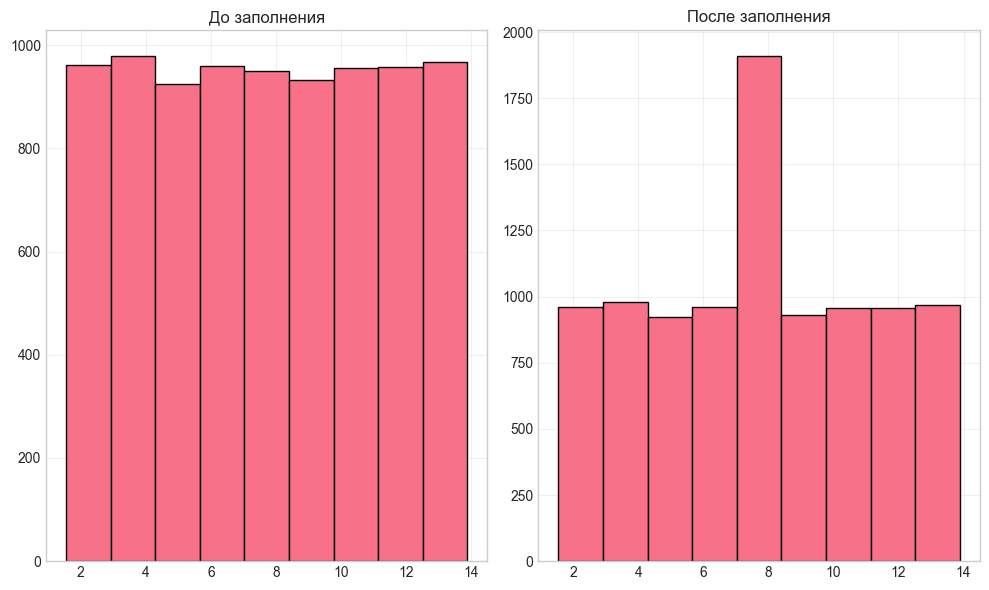

  Заполнение значением 7.7152: KL = 0.1061


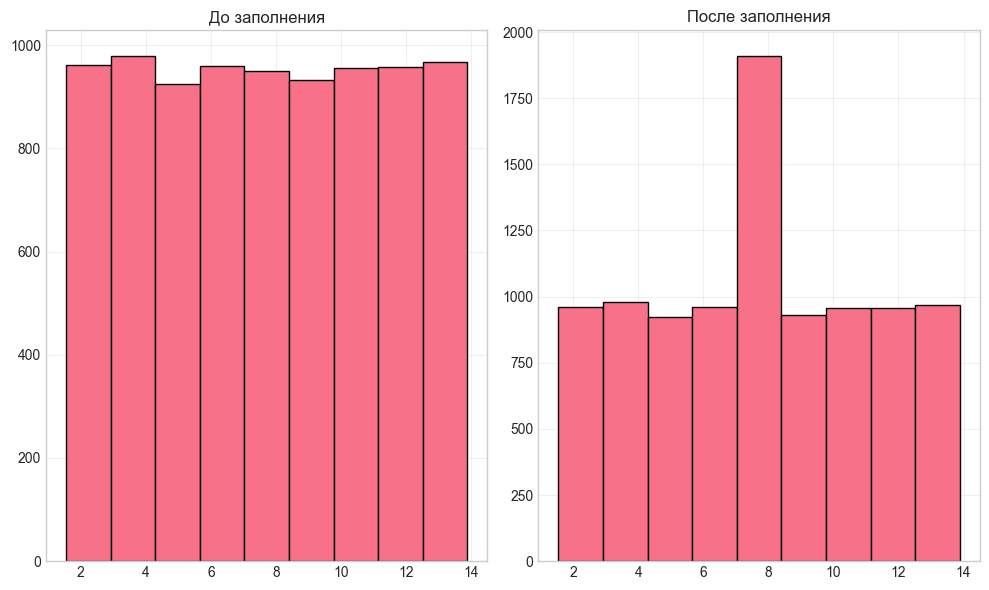

  Заполнение значением 7.7166: KL = 0.0288


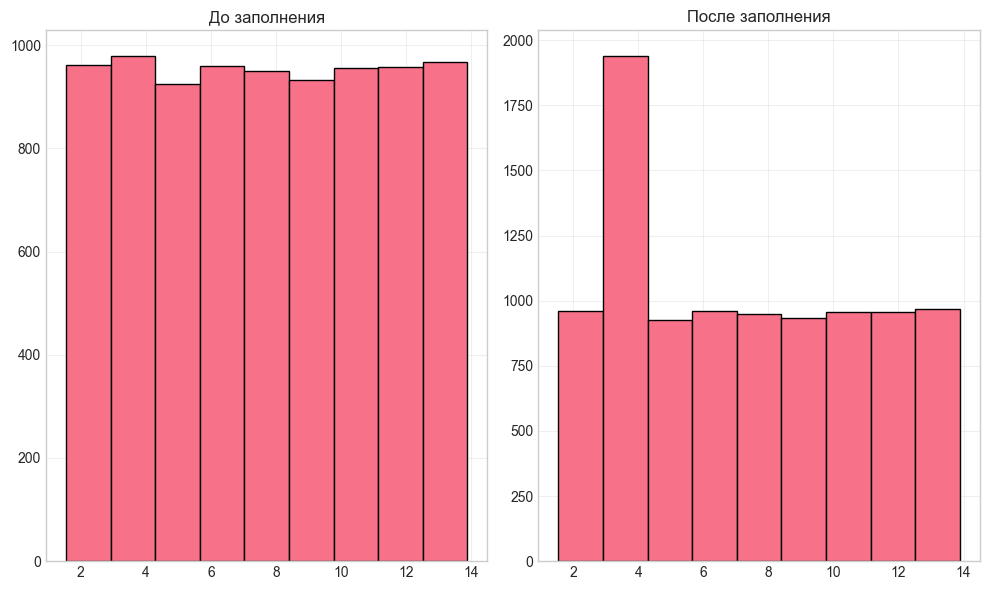

  Заполнение значением 3.0866: KL = 0.0281
  Выбрано значение: 3.0866 (KL = 0.0281)


In [63]:
best_values = {}
for col in missing_cols:
    print(f"\n--- Обработка признака: {col} ---")
    
    candidate_values = [
        X_train[col].mean(),
        X_train[col].median(),
        X_train[col].mode()[0]
    ]
    
    best_kl = float('inf')
    best_val = None
    
    for val in candidate_values:
        kl, _, _ = evaluate_imputation(X_train[col], val)
        print(f"  Заполнение значением {val:.4f}: KL = {kl:.4f}")
        if kl < best_kl:
            best_kl = kl
            best_val = val
    
    best_values[col] = best_val
    print(f"  Выбрано значение: {best_val:.4f} (KL = {best_kl:.4f})")

### 2.2.3. <a id='toc2_2_3_'></a>[Заполнение пропусков статистическими значениями в обучающей выборке](#toc0_)

In [64]:
X_train_stat = X_train.copy()
for col, val in best_values.items():
    X_train_stat[col] = X_train_stat[col].fillna(val)

print("Пропуски в обучающей выборке после статистического заполнения:")
print(X_train_stat.isna().sum())

Пропуски в обучающей выборке после статистического заполнения:
Вектор Мощи                       0
Скорость перехода через портал    0
Приток Силы Потока                0
Ритм магического ядра             0
Поток Энергий                     0
Сила Левого Потока                0
Пламя Стихий                      0
Приток давления Выдоха Истока     0
Давление выдоха Истока            0
Печать Чародея                    0
Эмульсия Истока                   0
Дыхание Истока                    0
Тип Вектора Мощи                  0
dtype: int64


### 2.2.4. <a id='toc2_2_4_'></a>[Машинный подход (KNNImputer)](#toc0_)


--- Обработка признака: Скорость перехода через портал ---


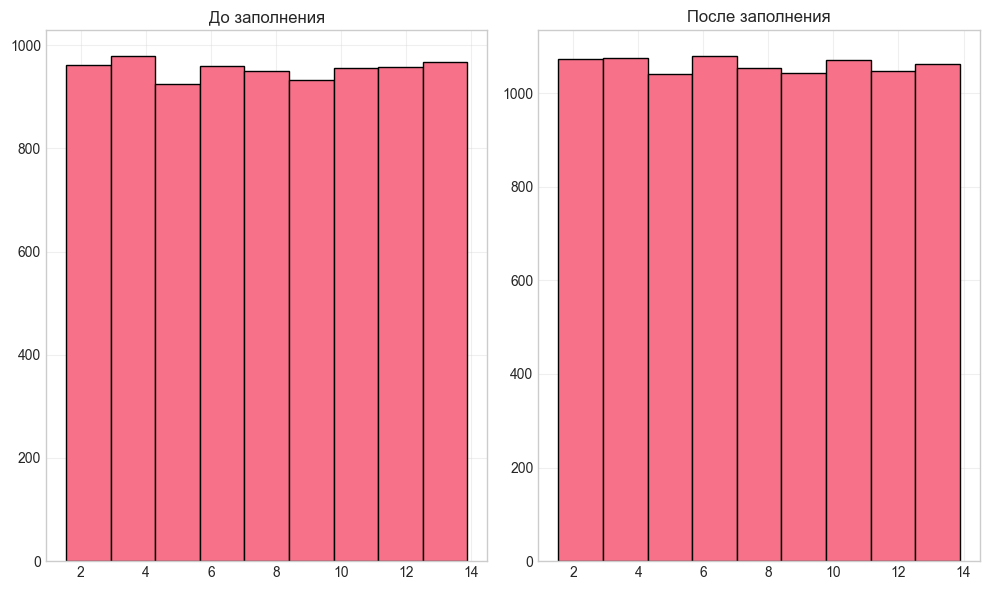

Пропуски в обучающей выборке после KNNImputer:
Вектор Мощи                       0
Скорость перехода через портал    0
Приток Силы Потока                0
Ритм магического ядра             0
Поток Энергий                     0
Сила Левого Потока                0
Пламя Стихий                      0
Приток давления Выдоха Истока     0
Давление выдоха Истока            0
Печать Чародея                    0
Эмульсия Истока                   0
Дыхание Истока                    0
Тип Вектора Мощи                  0
dtype: int64


In [65]:
imputer = KNNImputer(n_neighbors=5)
X_train_knn = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

for col in missing_cols:
    
    print(f"\n--- Обработка признака: {col} ---")

    plt.figure(figsize=(10, 6))

    plt.subplot(1, 2, 1)
    plt.hist(X_train[col].dropna(), bins=9, edgecolor='black', alpha=1)
    plt.title('До заполнения')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.hist(X_train_knn[col], bins=9, edgecolor='black', alpha=1)
    plt.title('После заполнения')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Пропуски в обучающей выборке после KNNImputer:")
print(X_train_knn.isna().sum())

### 2.2.5. <a id='toc2_2_5_'></a>[Применение результатов к тестовой выборке](#toc0_)

In [66]:
X_test_stat = X_test.copy()
for col, val in best_values.items():
    X_test_stat[col] = X_test_stat[col].fillna(val)

X_test_knn = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Пропуски в тестовой выборке после обработки:")
print("Статистический подход:")
print(X_test_stat.isna().sum())
print("\nМашинный подход (KNNImputer):")
print(X_test_knn.isna().sum())

Пропуски в тестовой выборке после обработки:
Статистический подход:
Вектор Мощи                       0
Скорость перехода через портал    0
Приток Силы Потока                0
Ритм магического ядра             0
Поток Энергий                     0
Сила Левого Потока                0
Пламя Стихий                      0
Приток давления Выдоха Истока     0
Давление выдоха Истока            0
Печать Чародея                    0
Эмульсия Истока                   0
Дыхание Истока                    0
Тип Вектора Мощи                  0
dtype: int64

Машинный подход (KNNImputer):
Вектор Мощи                       0
Скорость перехода через портал    0
Приток Силы Потока                0
Ритм магического ядра             0
Поток Энергий                     0
Сила Левого Потока                0
Пламя Стихий                      0
Приток давления Выдоха Истока     0
Давление выдоха Истока            0
Печать Чародея                    0
Эмульсия Истока                   0
Дыхание Истока          

## 2.3. <a id='toc2_3_'></a>[Дополнительное задание: оценка качества заполнения пропусков (NRMSE)](#toc0_)

### 2.3.1. <a id='toc2_3_1_'></a>[Создание «чистого» датасета](#toc0_)

In [67]:
X_train_clean = X_train.dropna().copy()
y_train_clean = y_train.loc[X_train_clean.index]

print(f"Исходный размер train: {X_train.shape}")
print(f"Чистый train (без пропусков): {X_train_clean.shape}")

Исходный размер train: (9547, 13)
Чистый train (без пропусков): (8586, 13)


### 2.3.2. <a id='toc2_3_2_'></a>[Генерация маскированных данных](#toc0_)

In [68]:
np.random.seed(42)
mask = np.random.rand(*X_train_clean.shape) < 0.1
X_train_masked = X_train_clean.mask(mask)
print(f"Количество пропусков в маскированных данных: {X_train_masked.isna().sum().sum()}")

Количество пропусков в маскированных данных: 11192


### 2.3.3. <a id='toc2_3_3_'></a>[Обучение KNNImputer на маскированных данных](#toc0_)

In [69]:
imputer_eval = KNNImputer(n_neighbors=5)
X_train_imputed = pd.DataFrame(imputer_eval.fit_transform(X_train_masked), columns=X_train_masked.columns, index=X_train_masked.index)

### 2.3.4. <a id='toc2_3_4_'></a>[Вычисление NRMSE](#toc0_)

In [70]:
def nrmse(original, imputed, mask):
    mse = mean_squared_error(original[mask], imputed[mask])
    rmse = np.sqrt(mse)
    nrmse_val = rmse / (original.max() - original.min())
    return nrmse_val

nrmse_results = {}
for col in X_train_clean.columns:
    original = X_train_clean[col]
    imputed = X_train_imputed[col]
    col_mask = mask[:, list(X_train_clean.columns).index(col)]
    nrmse_results[col] = nrmse(original, imputed, col_mask)

print("NRMSE для каждого признака:")
for col, val in nrmse_results.items():
    print(f"  {col}: {val:.6f}")

NRMSE для каждого признака:
  Вектор Мощи: 0.027625
  Скорость перехода через портал: 0.027705
  Приток Силы Потока: 0.006914
  Ритм магического ядра: 0.007826
  Поток Энергий: 0.008217
  Сила Левого Потока: 0.012949
  Пламя Стихий: 0.033863
  Приток давления Выдоха Истока: 0.005802
  Давление выдоха Истока: 0.014405
  Печать Чародея: 0.035109
  Эмульсия Истока: 0.010694
  Дыхание Истока: 0.165369
  Тип Вектора Мощи: 0.040833
